<a href="https://colab.research.google.com/github/TemplinB/TemplinB-ML-Xray/blob/main/ML_Project_Training_MNV2_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# ===== Packages =====

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import subprocess
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, GlobalAveragePooling2D, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import RandomRotation, RandomZoom, RandomTranslation, RandomContrast
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
# ===== Manage and Lock Kaggle Key =====

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [3]:
# ===== Check if Locked =====

# (Look for -rw----------)
!ls -l ~/.kaggle

total 4
-rw------- 1 root root 84 May  3 20:37 kaggle.json


In [4]:
# ===== Import Data (Kaggle) =====

print("Downloading dataset...")
subprocess.run(
    ["kaggle", "datasets", "download", "-d", "paultimothymooney/chest-xray-pneumonia"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL)

print("Download complete. Unzipping...")

subprocess.run(
    ["unzip", "-q", "chest-xray-pneumonia.zip"],)
print("Done!")

Download complete. Unzipping...
Done!


In [6]:
# ===== Dataset Contents =====

!ls /content
!ls /content/chest_xray

chest_xray  chest-xray-pneumonia.zip  kaggle.json  sample_data
chest_xray  __MACOSX  test  train  val


In [7]:
# ===== Separate Folder Contents =====

BASE_DIR = "/content/chest_xray/chest_xray"

train_dir = BASE_DIR + "/train"
test_dir = BASE_DIR + "/test"
val_dir = BASE_DIR + "/val"

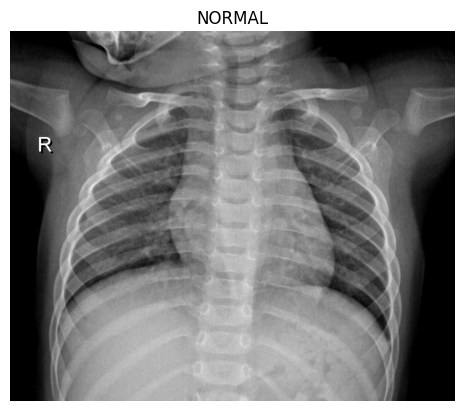

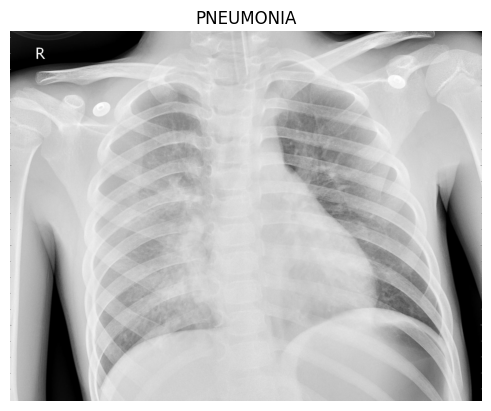

In [8]:
# ===== Validate Images =====

DATADIR = train_dir
CATEGORIES = ["NORMAL", "PNEUMONIA"]

for category in CATEGORIES:
    path = os.path.join(DATADIR, category)
    for image in os.listdir(path):
        image_array = cv2.imread(os.path.join(path, image), cv2.IMREAD_COLOR)
        image_array = cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB)
        plt.imshow(image_array)
        plt.title(category)
        plt.axis("off")
        plt.show()
        break

In [9]:
# ===== Create Training Dataset =====

training_data = []
IMAGE_SIZE = 128


def create_training_data():
    for category in CATEGORIES:
        path = os.path.join(DATADIR, category)
        class_num = CATEGORIES.index(category)

        for image in os.listdir(path):
            try:
                img_path = os.path.join(path, image)

                image_array = cv2.imread(img_path, cv2.IMREAD_COLOR)
                image_array = cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB)

                if image_array is None:
                    continue  # skip bad files

                new_array = cv2.resize(image_array, (IMAGE_SIZE, IMAGE_SIZE))
                training_data.append([new_array, class_num])

            except Exception as e:
                pass

create_training_data()
print(len(training_data))

5216


In [10]:
# ===== Shuffle Pneumonia Types =====

random.shuffle(training_data)

for sample in training_data[:10]:
  print(sample[1])

1
1
1
1
0
1
1
1
1
0


In [11]:
# ===== Image (X) & Labels (y) =====

X = []
y = []

for features, label in training_data:
  X.append(features)
  y.append(label)

X = np.array(X).reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 3)      # (All Images, Image Height, Image Width, RGB)
y = np.array(y)

X = X / 255.0

print(X.shape)
print(y.shape)

(5216, 128, 128, 3)
(5216,)


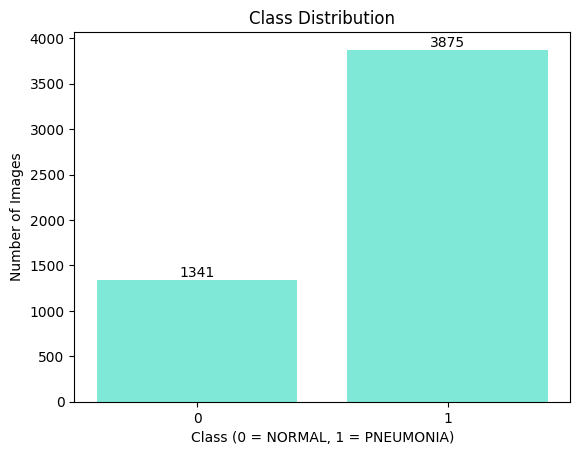

In [12]:
# ===== Check Class Imbalance =====

classes, counts = np.unique(y, return_counts=True)

plt.figure()

bars = plt.bar(classes.astype(str), counts, color="#7FE8D7")

plt.title("Class Distribution")
plt.xlabel("Class (0 = NORMAL, 1 = PNEUMONIA)")
plt.ylabel("Number of Images")

# Add numbers on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom'
    )

plt.show()

In [13]:
# ===== Calculate Weights =====

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y),
    y=y)

class_weight_balanced = {
    int(cls): float(weight)
    for cls, weight in zip(np.unique(y), class_weights_arr)}

print("Class Weights:", class_weight_balanced)

Class Weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


In [14]:
# ===== Load Test Set =====

test_data = []

def create_test_data():
    for category in CATEGORIES:
        path = os.path.join(test_dir, category)
        class_num = CATEGORIES.index(category)
        for image in os.listdir(path):
            try:
                img_path = os.path.join(path, image)
                image_array = cv2.imread(img_path, cv2.IMREAD_COLOR)
                image_array = cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB)
                if image_array is None:
                    continue
                new_array = cv2.resize(image_array, (IMAGE_SIZE, IMAGE_SIZE))
                test_data.append([new_array, class_num])
            except:
                pass

create_test_data()
print(len(test_data))

624


In [15]:
# ===== Shuffle Pneumonia Types =====

random.shuffle(test_data)

for sample in test_data[:10]:
  print(sample[1])

1
0
1
1
1
1
1
1
1
0


In [16]:
# ===== Image (X) & Labels (y) =====

X_test = []
y_test = []
for features, label in test_data:
    X_test.append(features)
    y_test.append(label)

X_test = np.array(X_test).reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 3)
y_test = np.array(y_test)

X_test = X_test / 255.0

print(X_test.shape)
print(y_test.shape)

(624, 128, 128, 3)
(624,)


In [17]:
# ===== Test Set Composition =====

classes, counts = np.unique(y_test, return_counts=True)

for cls, count in zip(classes, counts):
    print(f"{CATEGORIES[cls]}: {count}")

NORMAL: 234
PNEUMONIA: 390


In [ ]:
# ===== Model =====

tf.keras.backend.clear_session()

base_model = MobileNetV2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

inputs = tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation="sigmoid")(x)  # Binary: Normal vs Pneumonia

model = tf.keras.Model(inputs, outputs)

# Compile Model
model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=1e-4),
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,207,361 (4.61 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [ ]:
# ===== Callbacks =====

# Monitor Validation Loss
early_stop = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1)

class PredictionCheck(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        preds = (self.model.predict(X_test, verbose=0) > 0.5).astype("int32").flatten()
        normal_pred = np.sum(preds == 0)
        pneumonia_pred = np.sum(preds == 1)
        print(f"  → Predicted Normal: {normal_pred}, Pneumonia: {pneumonia_pred}")

In [ ]:
# ===== Train Model =====

history = model.fit(
    X, y,
    batch_size=32,
    epochs=30,
    validation_data=(X_test, y_test),
    class_weight=class_weight_balanced,
    callbacks=[early_stop, reduce_lr, PredictionCheck()]
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.8576 - loss: 0.2474  → Predicted Normal: 198, Pneumonia: 426
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 630ms/step - accuracy: 0.9298 - loss: 0.1551 - val_accuracy: 0.8622 - val_loss: 0.3202 - learning_rate: 1.0000e-04
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.9734 - loss: 0.0607  → Predicted Normal: 92, Pneumonia: 532
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 567ms/step - accuracy: 0.9787 - loss: 0.0543 - val_accuracy: 0.7628 - val_loss: 0.6760 - learning_rate: 1.0000e-04
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.9860 - loss: 0.0377
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
  → Predicted Normal: 121, Pneumonia: 503
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 632ms/step - accuracy: 0.9889 - loss: 0.0322 - val_accuracy: 0.8061 - val_loss: 0.5829 - learning_rate: 1.0000e-04
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.9945 - loss: 0.0191  → 

In [ ]:
# ===== Save Model =====

model.save("CNN_MNV2.keras")

In [ ]:
# ===== Confusion Matrix and Report =====

y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.6).astype("int32").flatten()

cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred, target_names=CATEGORIES))

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 431ms/step
[[193  41]
 [ 46 344]]
              precision    recall  f1-score   support

      NORMAL       0.81      0.82      0.82       234
   PNEUMONIA       0.89      0.88      0.89       390

    accuracy                           0.86       624
   macro avg       0.85      0.85      0.85       624
weighted avg       0.86      0.86      0.86       624



In [19]:
# ===== MobileNetV2 Model =====

tf.keras.backend.clear_session()

base_model = MobileNetV2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

inputs = tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=1e-4),
    metrics=["accuracy"]
)

# Callbacks
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)

class PredictionCheck(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        preds = (self.model.predict(X_test, verbose=0) > 0.5).astype("int32").flatten()
        normal_pred = np.sum(preds == 0)
        pneumonia_pred = np.sum(preds == 1)
        print(f"  → Predicted Normal: {normal_pred}, Pneumonia: {pneumonia_pred}")

history = model.fit(
    X, y,
    batch_size=32,
    epochs=30,
    validation_data=(X_test, y_test),
    class_weight=class_weight_balanced,
    callbacks=[early_stop, reduce_lr, PredictionCheck()]
)

model.save("CNN_MNV2.keras")

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.8759 - loss: 0.2908  → Predicted Normal: 14, Pneumonia: 610
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 621ms/step - accuracy: 0.9304 - loss: 0.1914 - val_accuracy: 0.6474 - val_loss: 1.3426 - learning_rate: 1.0000e-04
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.9763 - loss: 0.0922  → Predicted Normal: 166, Pneumonia: 458
163/163 ━━━━━━━━━━━━━━━━━━━━ 136s 586ms/step - accuracy: 0.9747 - loss: 0.0943 - val_accuracy: 0.8558 - val_loss: 0.3810 - learning_rate: 1.0000e-04
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.9847 - loss: 0.0627  → Predicted Normal: 240, Pneumonia: 384
163/163 ━━━━━━━━━━━━━━━━━━━━ 95s 583ms/step - accuracy: 0.9845 - loss: 0.0618 - val_accuracy: 0.8878 - val_loss: 0.3087 - learning_rate: 1.0000e-04
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.9945 - loss: 0.0426  → Predicted Normal: 233, Pneumonia: 391
163/163 ━━━━━━━━━━━━━━━━━━━━ 93s 568ms/

In [20]:
# ===== Confusion Matrix and Report =====

y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()

cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred, target_names=CATEGORIES))

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 579ms/step
[[205  29]
 [ 28 362]]
              precision    recall  f1-score   support

      NORMAL       0.88      0.88      0.88       234
   PNEUMONIA       0.93      0.93      0.93       390

    accuracy                           0.91       624
   macro avg       0.90      0.90      0.90       624
weighted avg       0.91      0.91      0.91       624



In [24]:
# ===== Threshold Testing =====

from sklearn.metrics import f1_score

for threshold in [0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7]:
    y_pred = (y_pred_probs > threshold).astype("int32").flatten()
    f1 = f1_score(y_test, y_pred, average="macro")
    normal_recall = np.sum((y_pred == 0) & (y_test == 0)) / np.sum(y_test == 0)
    pneumonia_recall = np.sum((y_pred == 1) & (y_test == 1)) / np.sum(y_test == 1)
    print(f"Threshold {threshold:.2f} → Macro F1: {f1:.3f} | Normal Recall: {normal_recall:.3f} | Pneumonia Recall: {pneumonia_recall:.3f}")

Threshold 0.30 → Macro F1: 0.896 | Normal Recall: 0.829 | Pneumonia Recall: 0.949
Threshold 0.40 → Macro F1: 0.895 | Normal Recall: 0.855 | Pneumonia Recall: 0.931
Threshold 0.45 → Macro F1: 0.897 | Normal Recall: 0.863 | Pneumonia Recall: 0.928
Threshold 0.50 → Macro F1: 0.902 | Normal Recall: 0.876 | Pneumonia Recall: 0.928
Threshold 0.55 → Macro F1: 0.894 | Normal Recall: 0.876 | Pneumonia Recall: 0.915
Threshold 0.60 → Macro F1: 0.898 | Normal Recall: 0.889 | Pneumonia Recall: 0.913
Threshold 0.70 → Macro F1: 0.889 | Normal Recall: 0.902 | Pneumonia Recall: 0.890


In [25]:
from google.colab import files
files.download("CNN_MNV2.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>